Regions used for clustering: 7
['East Midlands', 'London', 'North East', 'North West', 'South East', 'South West', 'West Midlands']


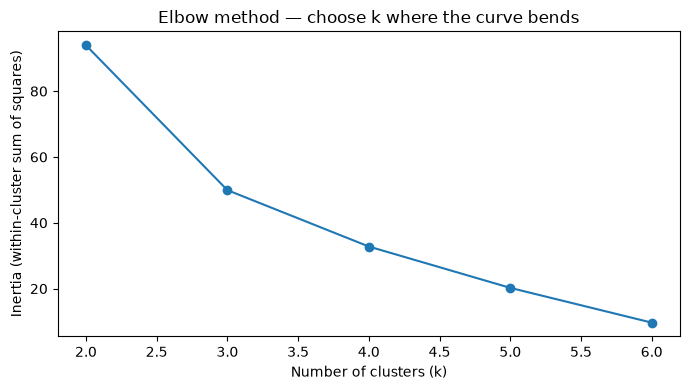

Elbow plot saved to elbow_plot.png

K-Means (K=3) — Region assignments:
       Region  Cluster  Pay_Resident  Pay_Workplace  Pay_Diff_Pct  Rental_Index
   North West        0       38209.6        38178.4     -0.081655         122.7
   North East        0       35989.2        35422.4     -1.574917         115.9
   South West        0       38168.0        37892.4     -0.722071         129.2
       London        1       46940.4        49826.4      6.148222         121.2
East Midlands        2       37481.6        36597.6     -2.358491         132.8
   South East        2       42390.4        40341.6     -4.833170         127.0
West Midlands        2       38012.0        37980.8     -0.082079         126.7


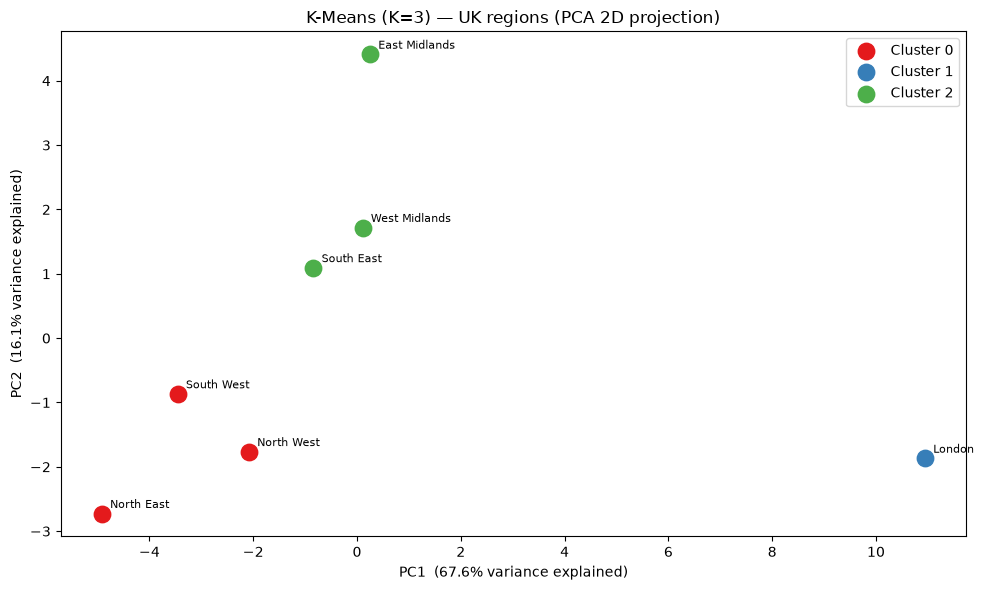

Cluster plot saved to kmeans_clusters.png

Cluster feature means:
         Pay_Resident  Pay_Workplace  Pay_Diff_Pct  Rental_Index
Cluster                                                         
0             37455.6        37164.4          -0.8         122.6
1             46940.4        49826.4           6.1         121.2
2             39294.7        38306.7          -2.4         128.8


In [2]:
import pandas as pd
import numpy as np
from functools import reduce
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")


# ── 1. ASHE pay — most recent year, full-time median, weekly → annual ─────────
def load_ashe(path, pay_col):
    df = pd.read_csv(path)
    df = df[
        (df["MEASURES"] == 20100) &
        (df["SEX_NAME"] == "Full Time Workers") &
        (df["ITEM_NAME"] == "Median") &
        (df["PAY_NAME"] == "Weekly pay - gross")
    ]
    latest = df["DATE"].max()
    df = df[df["DATE"] == latest][["GEOGRAPHY_NAME", "OBS_VALUE"]].copy()
    df.columns = ["Region", pay_col]
    df[pay_col] = pd.to_numeric(df[pay_col], errors="coerce") * 52
    return df.groupby("Region")[pay_col].mean().reset_index()


df_resident  = load_ashe("data/nomis_ashe_resident.csv",  "Pay_Resident")
df_workplace = load_ashe("data/nomis_ashe_workplace.csv", "Pay_Workplace")
df_pay = pd.merge(df_resident, df_workplace, on="Region")
df_pay["Pay_Diff_Pct"] = (
    (df_pay["Pay_Workplace"] - df_pay["Pay_Resident"]) / df_pay["Pay_Resident"] * 100
)


# ── 2. Rental price index — most recent index value per English region ────────
REGION_CODE_MAP = {
    "E12000001": "North East",
    "E12000002": "North West",
    "E12000003": "Yorkshire and The Humber",
    "E12000004": "East Midlands",
    "E12000005": "West Midlands",
    "E12000006": "East of England",
    "E12000007": "London",
    "E12000008": "South East",
    "E12000009": "South West",
}

df_rental = pd.read_csv("data/ons_index_private_housing_rental_prices.csv")
df_rental = df_rental[
    (df_rental["IndexAndYearChange"] == "Index") &
    (df_rental["administrative-geography"].isin(REGION_CODE_MAP))
].copy()
df_rental["Region"] = df_rental["administrative-geography"].map(REGION_CODE_MAP)
df_rental["Date"] = pd.to_datetime(df_rental["mmm-yy"], format="%b-%y")
df_rental = (
    df_rental.sort_values("Date")
    .groupby("Region")
    .last()[["v4_1"]]
    .reset_index()
    .rename(columns={"v4_1": "Rental_Index"})
)
df_rental["Rental_Index"] = pd.to_numeric(df_rental["Rental_Index"], errors="coerce")


# ── 3. Demographic features — aggregate local authority data to region ────────
loc_map = pd.read_csv("data/location_mapping.csv")
loc_map.columns = ["Local_area", "Region"]


def pivot_to_region_proportions(path, cat_col, area_col="Lower tier local authorities",
                                region_col=None, prefix=None):
    """Load a long-format census file, aggregate to region, pivot and normalise."""
    df = pd.read_csv(path)
    df = df[~df[cat_col].astype(str).str.startswith("Does not apply")]

    if region_col and region_col in df.columns:
        df = df.rename(columns={region_col: "Region"})
    else:
        df = df.merge(loc_map, left_on=area_col, right_on="Local_area", how="left")
        df = df.dropna(subset=["Region"])

    df_agg = df.groupby(["Region", cat_col])["Observation"].sum().reset_index()
    df_pivot = df_agg.pivot_table(index="Region", columns=cat_col,
                                  values="Observation", fill_value=0)
    df_pivot = df_pivot.div(df_pivot.sum(axis=1), axis=0)  # proportions

    short = prefix or cat_col.split("(")[0].strip().lower().replace(" ", "_")
    df_pivot.columns = [f"{short}_{c}" for c in df_pivot.columns]
    return df_pivot.reset_index()


df_religion = pivot_to_region_proportions(
    "data/religion_with_region.csv",
    cat_col="Religion (10 categories)",
    region_col="geography",
    prefix="rel",
)
df_sex = pivot_to_region_proportions(
    "data/sex.csv",
    cat_col="Sex (2 categories)",
    prefix="sex",
)
df_ethnic = pivot_to_region_proportions(
    "data/ethnic.csv",
    cat_col="Ethnic group (20 categories)",
    prefix="eth",
)


# ── 4. Merge all datasets on Region ──────────────────────────────────────────
dfs = [df_pay, df_rental, df_religion, df_sex, df_ethnic]
df_all = reduce(lambda l, r: pd.merge(l, r, on="Region", how="inner"), dfs)
df_all = df_all.dropna().reset_index(drop=True)

print(f"Regions used for clustering: {len(df_all)}")
print(df_all["Region"].tolist())


# ── 5. Scale features ─────────────────────────────────────────────────────────
regions  = df_all["Region"].copy()
features = df_all.drop(columns="Region")

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(features)


# ── 6. Elbow method — find the best k ────────────────────────────────────────
k_range = range(2, min(8, len(df_all)))
inertia = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow method — choose k where the curve bends")
plt.tight_layout()
plt.savefig("elbow_plot.png", dpi=150)
plt.show()
print("Elbow plot saved to elbow_plot.png")


# ── 7. Fit K-Means — adjust K after inspecting the elbow plot ────────────────
K = 3   # <-- change this after looking at the elbow plot

km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df_all["Cluster"] = km_final.fit_predict(X_scaled)

print(f"\nK-Means (K={K}) — Region assignments:")
display_cols = ["Region", "Cluster", "Pay_Resident", "Pay_Workplace",
                "Pay_Diff_Pct", "Rental_Index"]
print(df_all[display_cols].sort_values("Cluster").to_string(index=False))


# ── 8. PCA scatter — visualise clusters in 2D ────────────────────────────────
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

colours = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]
plt.figure(figsize=(10, 6))
for c in sorted(df_all["Cluster"].unique()):
    mask = df_all["Cluster"] == c
    plt.scatter(coords[mask, 0], coords[mask, 1],
                color=colours[c % len(colours)],
                label=f"Cluster {c}", s=140, zorder=3)
    for i in df_all[mask].index:
        plt.annotate(regions.iloc[i], (coords[i, 0], coords[i, 1]),
                     textcoords="offset points", xytext=(6, 4), fontsize=8)

plt.xlabel(f"PC1  ({pca.explained_variance_ratio_[0]:.1%} variance explained)")
plt.ylabel(f"PC2  ({pca.explained_variance_ratio_[1]:.1%} variance explained)")
plt.title(f"K-Means (K={K}) — UK regions (PCA 2D projection)")
plt.legend()
plt.tight_layout()
plt.savefig("kmeans_clusters.png", dpi=150)
plt.show()
print("Cluster plot saved to kmeans_clusters.png")


# ── 9. Cluster summary ────────────────────────────────────────────────────────
summary = df_all.groupby("Cluster")[
    ["Pay_Resident", "Pay_Workplace", "Pay_Diff_Pct", "Rental_Index"]
].mean().round(1)
print("\nCluster feature means:")
print(summary)



